In [3]:
print("Thabanya let's get started") 

Thabanya let's get started


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train=pd.read_csv(r"C:\Data Science\Walmart sales forecasting\Data/train.csv")
print(train.head)
train.shape
train.isnull().sum()
train.columns

<bound method NDFrame.head of         Store  Dept        Date  Weekly_Sales  IsHoliday
0           1     1  2010-02-05      24924.50      False
1           1     1  2010-02-12      46039.49       True
2           1     1  2010-02-19      41595.55      False
3           1     1  2010-02-26      19403.54      False
4           1     1  2010-03-05      21827.90      False
...       ...   ...         ...           ...        ...
421565     45    98  2012-09-28        508.37      False
421566     45    98  2012-10-05        628.10      False
421567     45    98  2012-10-12       1061.02      False
421568     45    98  2012-10-19        760.01      False
421569     45    98  2012-10-26       1076.80      False

[421570 rows x 5 columns]>


Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='str')

In [6]:
stores=pd.read_csv(r"C:\Data Science\Walmart sales forecasting\Data/stores.csv")
test=pd.read_csv(r"C:\Data Science\Walmart sales forecasting\Data/test.csv")
print(test.shape)

(115064, 4)


In [7]:
train= train.merge(stores, on='Store', how='left')
print(train.shape)
print(train.head)

(421570, 7)
<bound method NDFrame.head of         Store  Dept        Date  Weekly_Sales  IsHoliday Type    Size
0           1     1  2010-02-05      24924.50      False    A  151315
1           1     1  2010-02-12      46039.49       True    A  151315
2           1     1  2010-02-19      41595.55      False    A  151315
3           1     1  2010-02-26      19403.54      False    A  151315
4           1     1  2010-03-05      21827.90      False    A  151315
...       ...   ...         ...           ...        ...  ...     ...
421565     45    98  2012-09-28        508.37      False    B  118221
421566     45    98  2012-10-05        628.10      False    B  118221
421567     45    98  2012-10-12       1061.02      False    B  118221
421568     45    98  2012-10-19        760.01      False    B  118221
421569     45    98  2012-10-26       1076.80      False    B  118221

[421570 rows x 7 columns]>


In [8]:
test = test.merge(stores, on='Store', how='left')
print(test.shape)
print(test.head)

(115064, 6)
<bound method NDFrame.head of         Store  Dept        Date  IsHoliday Type    Size
0           1     1  2012-11-02      False    A  151315
1           1     1  2012-11-09      False    A  151315
2           1     1  2012-11-16      False    A  151315
3           1     1  2012-11-23       True    A  151315
4           1     1  2012-11-30      False    A  151315
...       ...   ...         ...        ...  ...     ...
115059     45    98  2013-06-28      False    B  118221
115060     45    98  2013-07-05      False    B  118221
115061     45    98  2013-07-12      False    B  118221
115062     45    98  2013-07-19      False    B  118221
115063     45    98  2013-07-26      False    B  118221

[115064 rows x 6 columns]>


In [9]:

train[train['Weekly_Sales'] < 0]

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
846,1,6,2012-08-10,-139.65,False,A,151315
2384,1,18,2012-05-04,-1.27,False,A,151315
6048,1,47,2010-02-19,-863.00,False,A,151315
6049,1,47,2010-03-12,-698.00,False,A,151315
6051,1,47,2010-10-08,-58.00,False,A,151315
...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,True,B,118221
419598,45,80,2010-02-19,-0.27,False,B,118221
419603,45,80,2010-04-16,-1.61,False,B,118221
419614,45,80,2010-07-02,-0.27,False,B,118221


In [10]:
negative_sales = train[train['Weekly_Sales'] < 0]
neg_by_store = negative_sales.groupby('Store')['Weekly_Sales'].count().sort_values(ascending=False)

print(neg_by_store.head(10))

Store
35    124
18     52
10     50
17     49
15     45
42     44
22     41
31     39
20     38
16     38
Name: Weekly_Sales, dtype: int64


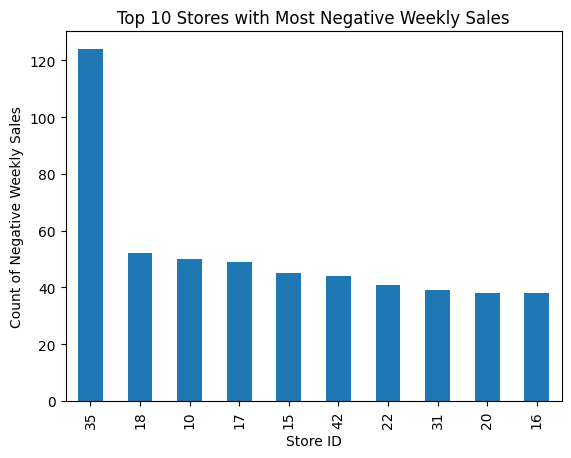

<Figure size 640x480 with 0 Axes>

In [11]:
neg_by_store.head(10).plot(kind='bar')
plt.xlabel("Store ID")
plt.ylabel("Count of Negative Weekly Sales")
plt.title("Top 10 Stores with Most Negative Weekly Sales")
plt.figure()
plt.show()

In [12]:
neg_by_type = negative_sales.groupby('Type')['Weekly_Sales'].count()
print("Negative sales count by Store Type:")
print(neg_by_type)


Negative sales count by Store Type:
Type
A    485
B    676
C    124
Name: Weekly_Sales, dtype: int64


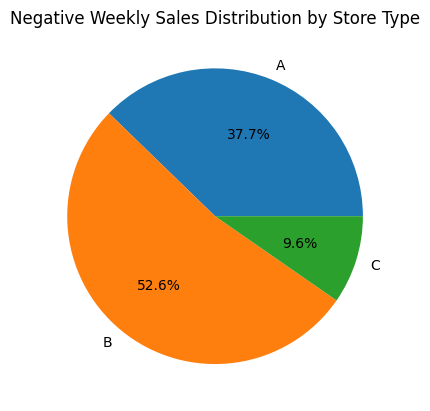

<Figure size 640x480 with 0 Axes>

In [13]:
plt.pie(neg_by_type, labels=neg_by_type.index, autopct='%1.1f%%')
plt.title("Negative Weekly Sales Distribution by Store Type")
plt.figure()
plt.show()

In [14]:
total_type = train.groupby('Type')['Weekly_Sales'].count()
negative_type = train[train['Weekly_Sales'] < 0].groupby('Type')['Weekly_Sales'].count()
analysis = pd.concat([total_type, negative_type], axis=1)
analysis.columns = ['Total_Rows', 'Negative_Rows']
analysis['Negative_Ratio_%'] = (analysis['Negative_Rows'] / analysis['Total_Rows']) * 100
print(analysis)


      Total_Rows  Negative_Rows  Negative_Ratio_%
Type                                             
A         215478            485          0.225081
B         163495            676          0.413468
C          42597            124          0.291100


In [15]:
train[train['Weekly_Sales'] < 0].groupby(['Type','Date']).size()

Type  Date      
A     2010-02-05    3
      2010-02-12    1
      2010-02-19    3
      2010-02-26    3
      2010-03-05    3
                   ..
C     2012-08-24    2
      2012-09-21    2
      2012-09-28    2
      2012-10-12    1
      2012-10-26    1
Length: 359, dtype: int64

In [16]:
train[train['Weekly_Sales'] < 0].groupby(['Type','Dept']).size().sort_values(ascending=False)

Type  Dept
A     47      132
B     47      122
A     18       97
B     18       80
      94       77
             ... 
C     12        1
      41        1
      34        1
      56        1
      85        1
Length: 84, dtype: int64

In [17]:
train[train['Weekly_Sales'] < 0].groupby(['Type','IsHoliday']).size()

Type  IsHoliday
A     False        460
      True          25
B     False        613
      True          63
C     False        114
      True          10
dtype: int64

In [18]:
# Total sales by Store
store_performance = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

print(store_performance.head(10))

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64


In [19]:
# Convert Date
train['Date'] = pd.to_datetime(train['Date'])

# Summary per Store
store_summary = train.groupby(['Store','Type']).agg(
    Total_Sales = ('Weekly_Sales','sum'),
    Avg_Weekly_Sales = ('Weekly_Sales','mean'),
    Num_Departments = ('Dept','nunique'),
    Num_Weeks = ('Date','nunique')
).reset_index()

# Sort by Total Sales
store_summary = store_summary.sort_values(by='Total_Sales', ascending=False)

print(store_summary)

    Store Type   Total_Sales  Avg_Weekly_Sales  Num_Departments  Num_Weeks
19     20    A  3.013978e+08      29508.301592               78        143
3       4    A  2.995440e+08      29161.210415               78        143
13     14    A  2.889999e+08      28784.851727               77        143
12     13    A  2.865177e+08      27355.136891               79        143
1       2    A  2.753824e+08      26898.070031               78        143
9      10    B  2.716177e+08      26332.303819               77        143
26     27    A  2.538559e+08      24826.984536               78        143
5       6    A  2.237561e+08      21913.243624               77        143
0       1    A  2.224028e+08      21710.543621               77        143
38     39    A  2.074455e+08      21000.763562               75        143
18     19    A  2.066349e+08      20362.126734               79        143
30     31    A  1.996139e+08      19681.907464               76        143
22     23    B  1.987506e

In [20]:
type_total = train.groupby('Type')['Weekly_Sales'].sum().sort_values(ascending=False)

print(type_total)

Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64


Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


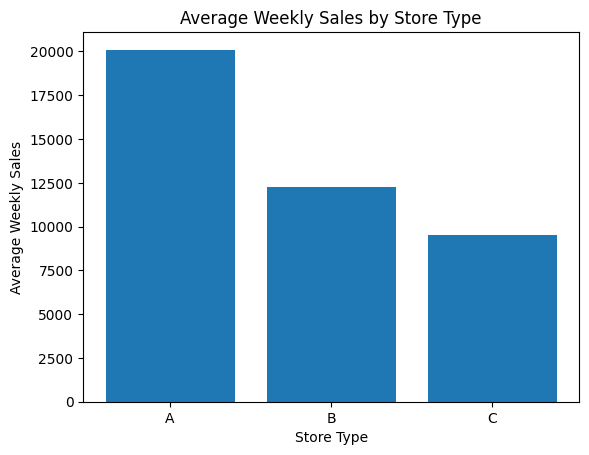

In [21]:
type_avg = train.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)

print(type_avg)
plt.figure()
plt.bar(type_avg.index, type_avg.values)
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.title("Average Weekly Sales by Store Type")
plt.show()

In [22]:
train.groupby('Type')['Store'].nunique()

Type
A    22
B    17
C     6
Name: Store, dtype: int64

In [23]:
train.groupby('Type')['Size'].mean()

Type
A    182231.285486
B    101818.735827
C     40535.725286
Name: Size, dtype: float64

In [24]:
train['Date'] = pd.to_datetime(train['Date'])
train['Month'] = train['Date'].dt.month

monthly_sales = train.groupby('Month')['Weekly_Sales'].sum()

print(monthly_sales)

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


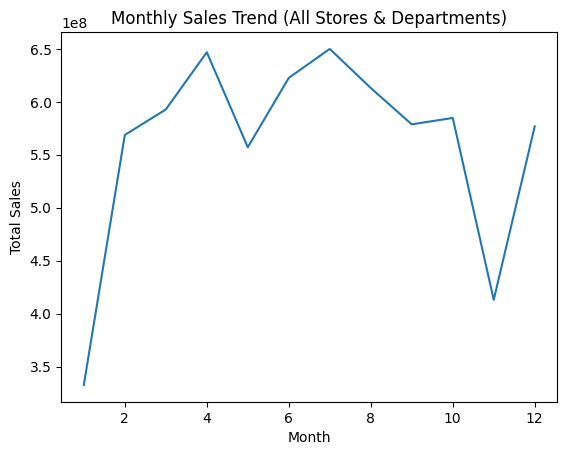

In [25]:
plt.figure()
monthly_sales.plot()
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend (All Stores & Departments)")
plt.show()

In [26]:
holiday_sales = train.groupby('IsHoliday')['Weekly_Sales'].sum()

print(holiday_sales)

holiday_avg = train.groupby('IsHoliday')['Weekly_Sales'].mean()

print(holiday_avg)

IsHoliday
False    6.231919e+09
True     5.052996e+08
Name: Weekly_Sales, dtype: float64
IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


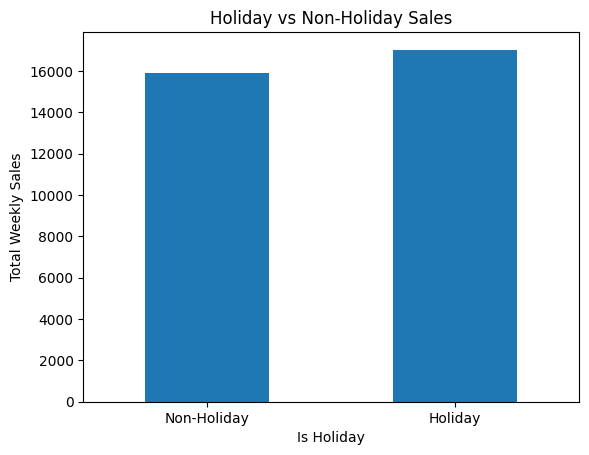

In [27]:
plt.figure()
holiday_avg.plot(kind='bar')

plt.xlabel("Is Holiday")
plt.ylabel("Total Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.xticks([0,1], ['Non-Holiday','Holiday'], rotation=0)

plt.show()

In [28]:
train.groupby(['Type','IsHoliday'])['Weekly_Sales'].mean()

Type  IsHoliday
A     False        20008.746759
      True         21297.517824
B     False        12153.067752
      True         13346.164062
C     False         9518.528116
      True          9532.963131
Name: Weekly_Sales, dtype: float64

In [29]:
dept_total = train.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

print(dept_total.head(10))

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64


In [30]:
train['Date'] = pd.to_datetime(train['Date'])
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month

In [31]:
#week index
train['Week'] = train['Date'].dt.isocalendar().week

In [32]:
train[['Date','Year','Month','Week']].head(10)

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9
5,2010-03-12,2010,3,10
6,2010-03-19,2010,3,11
7,2010-03-26,2010,3,12
8,2010-04-02,2010,4,13
9,2010-04-09,2010,4,14


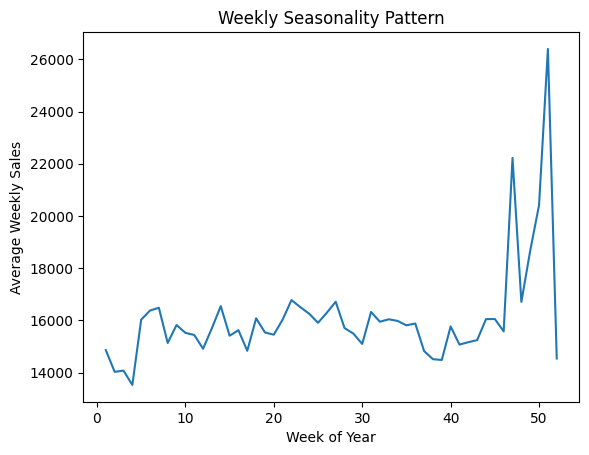

In [33]:
#week seasonality pattern
weekly_pattern = train.groupby('Week')['Weekly_Sales'].mean()
plt.figure()
weekly_pattern.plot()
plt.xlabel("Week of Year")
plt.ylabel("Average Weekly Sales")
plt.title("Weekly Seasonality Pattern")
plt.show()

Index(['Store', 'Dept', 'Weekly_Sales', 'Size'], dtype='str')


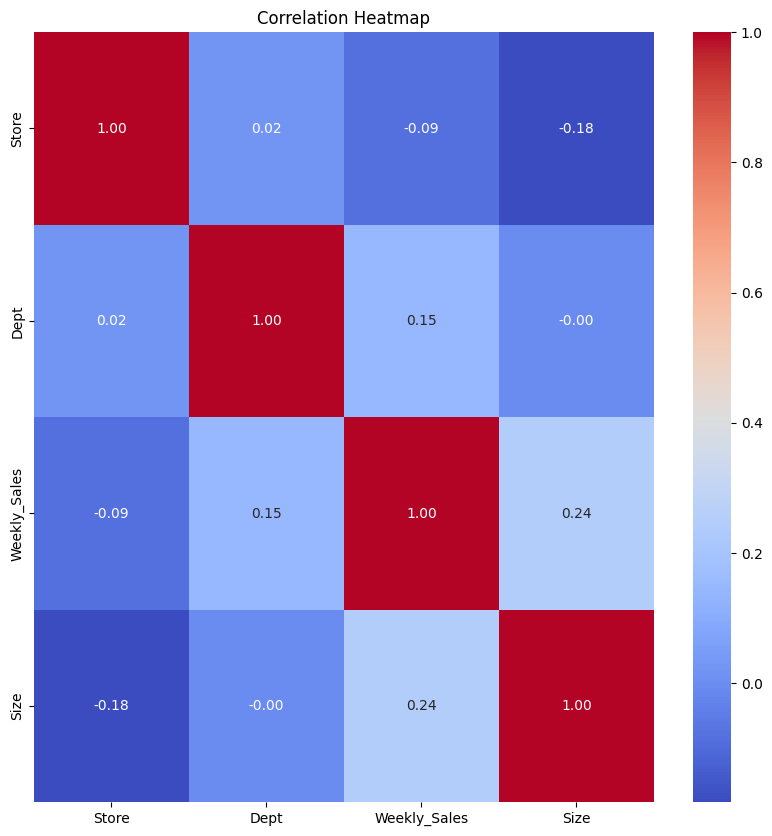

In [34]:
numeric_cols = train.select_dtypes(include=['int64','float64']).columns
print(numeric_cols)
corr_matrix = train[numeric_cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [35]:
pivot_store_dept = pd.pivot_table(
    train,
    values='Weekly_Sales',
    index=['Type','Store'],
    columns='Dept',
    aggfunc='mean'
)

pivot_store_dept.head()

Dept                  1             2             3             4   \
Type Store                                                           
A    1      22513.322937  46102.090420  13150.478042  36964.154476   
     2      30777.980769  65912.922517  17476.563357  45607.666573   
     4      36979.940070  93639.315385  19012.491678  56603.400140   
     6      23867.553776  50269.437273  16806.638811  34187.366503   
     8      14789.827343  35729.821748  10683.305105  21089.309301   

Dept                  5            6             7             8   \
Type Store                                                          
A    1      24257.941119  4801.780140  24566.487413  35718.257622   
     2      30555.315315  6808.382517  40477.837063  58707.369441   
     4      45668.406783  8241.777692  50728.151399  62949.723776   
     6      34465.307622  7225.566643  34526.870420  47577.719790   
     8      19838.849231  3395.425455  20268.743776  26438.524336   

Dept                  9             10  ...            90            91  \
Type Store                              ...                               
A    1      28062.052238  31033.386364  ...  82427.547832  64238.943427   
     2      34375.864476  38845.854476  ...  97611.537133  80610.380350   
     4      34437.170979  37269.667413  ...  89248.965524  66535.407203   
     6      48271.060140  47436.477902  ...  53715.366084  45270.405175   
     8      11792.661678  20666.433776  ...  39333.566154  31530.560909   

Dept                   92            93            94             95  \
Type Store                                                             
A    1      135458.969510  71699.182378  63180.568182  120772.062168   
     2      164840.230979  70581.977063  70018.672517  143588.751888   
     4      159365.107902  67815.163007  68159.106573  147236.473706   
     6       99024.796503  41359.651189  41701.693497   89208.786294   
     8       60465.630000  27515.635315  25442.578042   62951.463706   

Dept                  96            97            98          99  
Type Store                                                        
A    1      33251.831639  35207.348811  11827.770769  306.091081  
     2      34319.063846  40697.204056  14035.400839  475.896905  
     4      38346.573077  39339.238951  15009.249371  623.182381  
     6      30450.542238  20637.667063   9728.100629  388.636750  
     8         16.986667  16978.366503   6880.466434  298.153714  

[5 rows x 81 columns]

In [36]:
train.select_dtypes(include='object').columns

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2264\3205410428.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.select_dtypes(include='object').columns


Index(['Type'], dtype='str')

In [37]:
pip install sklearn


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn (from versions: none)
ERROR: No matching distribution found for sklearn

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Type'] = le.fit_transform(train['Type'])

In [39]:
train.select_dtypes(include='object').columns

Index([], dtype='str')

In [40]:
y = train['Weekly_Sales']
X = train.drop(columns=['Weekly_Sales','Date'])

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(((y_val - y_pred_lr) ** 2).mean())
r2_lr = r2_score(y_val, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 14571.19463884832
RMSE: 21814.06938838265
R2: 0.08747824945131644


In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(((y_val - y_pred_rf) ** 2).mean())
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 1339.7058026140378
RMSE: 3510.9048260839577
R2: 0.9763621507884924


In [45]:
pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=200,      # number of trees
    learning_rate=0.05,    # step size
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [47]:
y_pred = xgb_model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(((y_val - y_pred_rf) ** 2).mean())
r2 = r2_score(y_val, y_pred)

print("XGBoost Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost Performance:
MAE: 4207.5575335530175
RMSE: 3510.9048260839577
R2: 0.8914721673962289


In [48]:
print("Linear R2:", r2_lr)
print("RF R2:", r2_rf)
print("R2:", r2)

Linear R2: 0.08747824945131644
RF R2: 0.9763621507884924
R2: 0.8914721673962289


In [49]:
#feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head()

Dept     0.625254
Size     0.212681
Store    0.072847
Week     0.055173
Type     0.015097
dtype: float64

In [50]:
y_test_pred = rf.predict(X_val)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_test = mean_absolute_error(y_val, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_val, y_test_pred))
r2_test = r2_score(y_val, y_test_pred)

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)
print("Test R2:", r2_test)

Test MAE: 1339.7058026140378
Test RMSE: 3510.9048260839577
Test R2: 0.9763621507884924


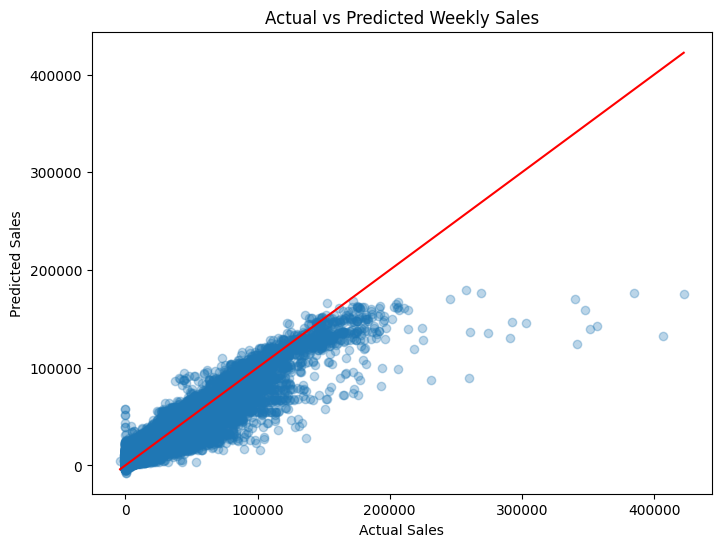

In [52]:
#Actual vs predicted sales:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.show()

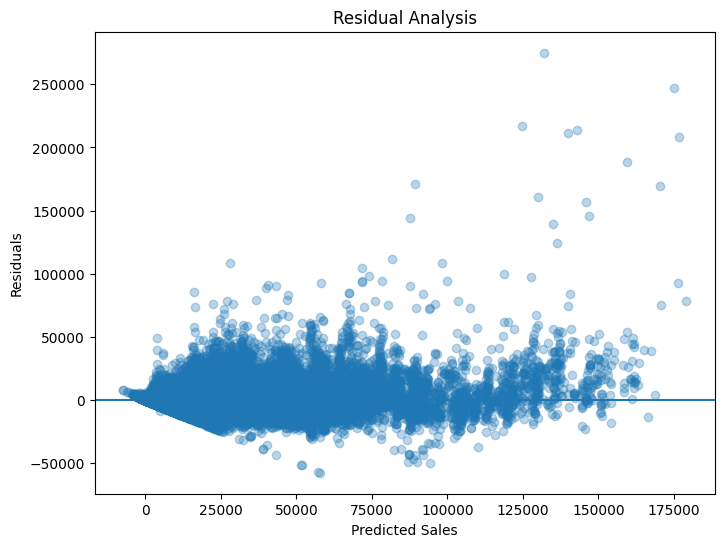

In [53]:
residuals = y_val - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

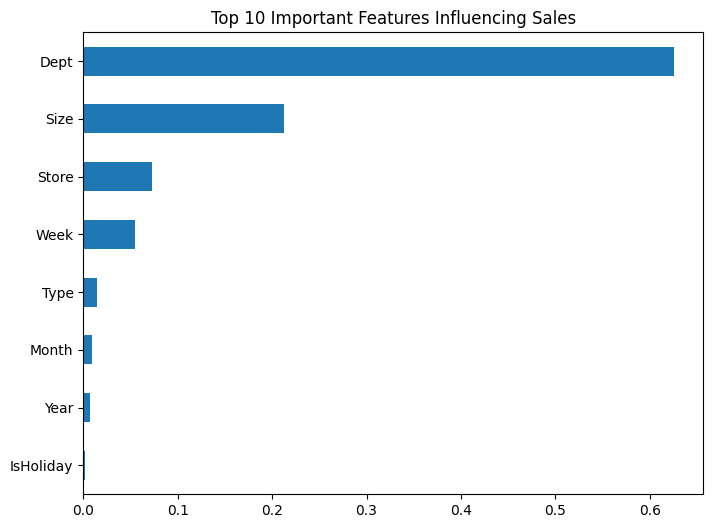

In [54]:

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features Influencing Sales")
plt.gca().invert_yaxis()
plt.show()

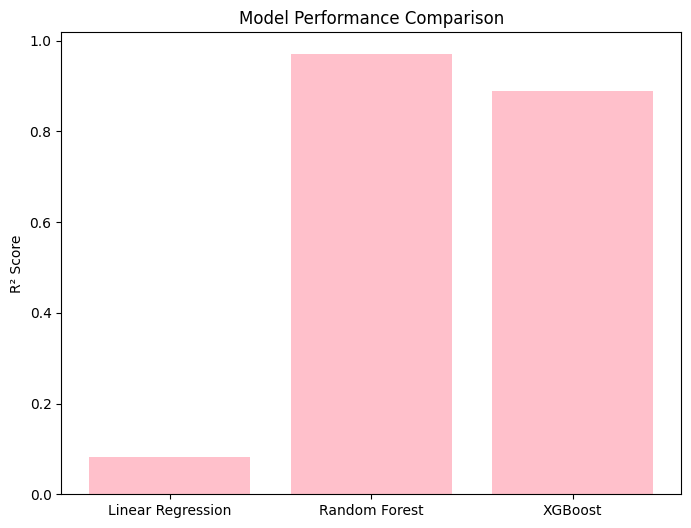

In [56]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [0.082, 0.97, 0.89]  # use your actual values

plt.figure(figsize=(8,6))
plt.bar(models, r2_scores, color='pink')
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

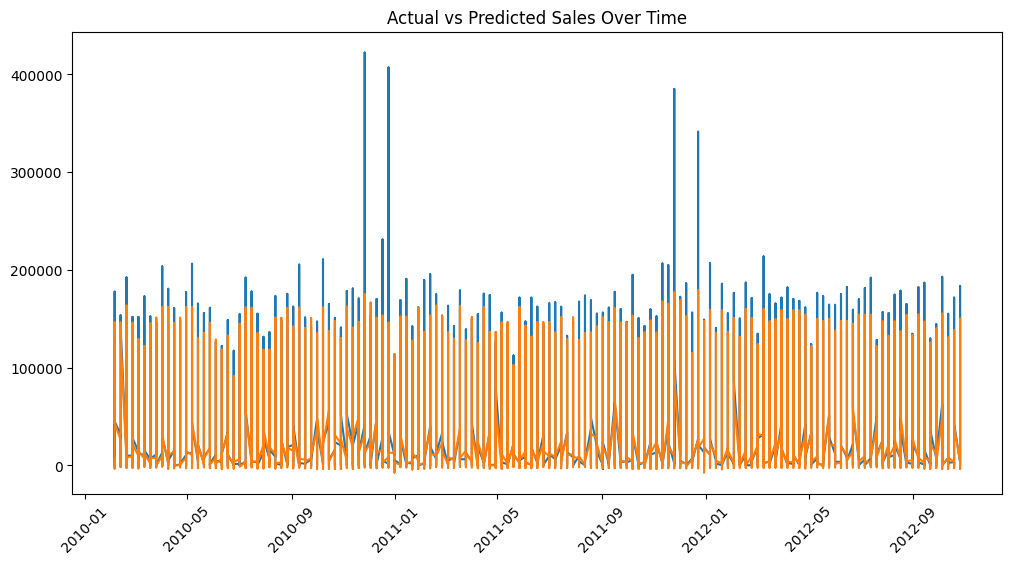

In [58]:
#Time series
comparison_df = pd.DataFrame({
    'Date': train.loc[y_val.index, 'Date'],
    'Actual': y_val,
    'Predicted': y_pred
}).sort_values('Date')

plt.figure(figsize=(12,6))
plt.plot(comparison_df['Date'], comparison_df['Actual'])
plt.plot(comparison_df['Date'], comparison_df['Predicted'])
plt.title("Actual vs Predicted Sales Over Time")
plt.xticks(rotation=45)
plt.show()